# Reconstruct multiple quadrupole errors with pyLOCO

##  objectives

Start from an ideal accelerator model, assign several known quadrupole errors, observe how they change the orbit response matrix (ORM), and use pyLOCO to reconstruct and correct them.

**Workflow:** ideal lattice → assign quadrupole errors → ORM changes → simulate BPM noise → pyLOCO fit → reconstruct and correct the errors.

## 1. Imports and configuration

The YAML file contains user-selectable values. Python configuration structures such as `FitInitConfig` belong to `pyLOCO.config`.

In [1]:
from copy import deepcopy
from tempfile import TemporaryDirectory
import at
import matplotlib.pyplot as plt
import numpy as np
from pyLOCO.config import FitInitConfig
from pyLOCO.analysis import plot_matrices
from pyLOCO.pyloco import pyloco
from pyLOCO.response_matrix import response_matrix
from example_multiple_quad_errors import (HERE, apply_quadrupole_changes, assign_quadrupole_error, element_indices, load_config, optics_beta, orm_config, print_optics_summary)

In [2]:
config_path = HERE / 'pyloco_config.yaml'
cfg = load_config(config_path)
cfg

{'lattice': {'file': 'betamodel.mat', 'use': 'betamodel'},
 'elements': {'bpm_type': 'Monitor',
  'corrector_pattern': 'S[HFDIJ]*',
  'quad_groups': ['QD3[AE]*', 'QF4[ABDE]*', 'QD5[BD]*']},
 'assigned_errors': [{'quad_index': 42, 'relative_error': 0.05},
  {'quad_index': 1512, 'relative_error': -0.03},
  {'quad_index': 2948, 'relative_error': 0.02}],
 'measurement': {'corrector_kick_rad': 0.0001,
  'bpm_noise_rms_m': 1e-07,
  'random_seed': 20260811},
 'rf': {'frequency_hz': 352372169.3993786, 'step_hz': 200.0},
 'loco': {'nIter': 3,
  'nLMIter': 8,
  'Starting_Lambda': 0.001,
  'max_lm_lambda': 15.0,
  'scaled': True,
  'svd_selection_method': 'threshold',
  'svd_threshold': 1e-07,
  'cut': None,
  'remove_coupling': True,
  'apply_normalization': False,
  'normalization_mode': 'component'},
 'output': {'directory': 'output/multiple_quad_errors'}}

## 2. Load the ideal AT lattice

This lattice is the initial model supplied to LOCO. It  contains none of the simulated machine error.

In [3]:
lattice_path = config_path.parent / cfg['lattice']['file']
ideal = at.load_lattice(lattice_path, use=cfg['lattice']['use'])
ideal.disable_6d()
bpm_indices, corrector_indices, quad_indices = element_indices(ideal, cfg)
cavity_indices = np.asarray(at.get_refpts(ideal, at.elements.RFCavity), dtype=int)
print(f'{len(ideal)} lattice elements')
print(f'{len(bpm_indices)} BPMs, {len(corrector_indices)} correctors, {len(quad_indices)} fitted quadrupoles')

4434 lattice elements
320 BPMs, 288 correctors, 252 fitted quadrupoles


## 3. Inspect the selected quadrupoles

The normalized quadrupole gradient $K$ has units of m⁻². Positive and negative values focus opposite transverse planes. In AT, a normal quadrupole's `K` and `PolynomB[1]` describe the same strength and must remain consistent.

In [4]:
assigned_specs = cfg['assigned_errors']
print(f'{"Name":<7} {"Index":>6} {"s [m]":>10} {"Nominal K [m^-2]":>20} {"Assigned [%]":>14}')
for spec in assigned_specs:
    index = int(spec['quad_index'])
    element = ideal[index]
    s_pos = float(np.asarray(at.get_s_pos(ideal, index)).item())
    print(f'{element.FamName:<7} {index:6d} {s_pos:10.3f} {element.K:20.9e} {100*float(spec["relative_error"]):14.6f}')

Name     Index      s [m]     Nominal K [m^-2]   Assigned [%]
QF4B        42      7.089      2.405629752e+00       5.000000
QD3E      1512    284.416     -2.305265274e+00      -3.000000
QD5B      2948    562.003     -2.770306269e+00       2.000000


## 4. Create the simulated machine

The ideal lattice remains LOCO's starting model. A deep copy represents the machine, and only that copy receives the configured error.

In [5]:
machine = deepcopy(ideal)
assigned = []
for spec in assigned_specs:
    index = int(spec['quad_index'])
    nominal_k, assigned_dk = assign_quadrupole_error(machine, index, float(spec['relative_error']))
    assigned.append((index, nominal_k, assigned_dk))
print(f'Assigned {len(assigned)} quadrupole errors to the machine copy.')

Assigned 3 quadrupole errors to the machine copy.


### Verify that the error was applied consistently



In [6]:
for index, nominal_k, assigned_dk in assigned:
    assert np.isclose(machine[index].K, machine[index].PolynomB[1])
    print(f'{ideal[index].FamName} [{index}]: K ideal={nominal_k:+.9e}, machine={machine[index].K:+.9e}, ΔK={assigned_dk:+.9e} m^-2')

QF4B [42]: K ideal=+2.405629752e+00, machine=+2.525911240e+00, ΔK=+1.202814876e-01 m^-2
QD3E [1512]: K ideal=-2.305265274e+00, machine=-2.236107315e+00, ΔK=+6.915795821e-02 m^-2
QD5B [2948]: K ideal=-2.770306269e+00, machine=-2.825712394e+00, ΔK=-5.540612537e-02 m^-2


## 5. Calculate the ideal ORM

An ORM entry is the BPM displacement produced by the configured corrector kick. Equivalently, after normalization by the kick, $R_{ij}=\Delta x_i/\Delta\theta_j$.

In [7]:
measurement_cfg = cfg['measurement']
kick_rad = float(measurement_cfg['corrector_kick_rad'])
rm_cfg = orm_config(bpm_indices, corrector_indices, kick_rad)
orm_ideal = response_matrix(ideal, config=rm_cfg)
print(f'Ideal ORM shape: {orm_ideal.shape}')
print(f'Ideal ORM RMS: {1e6 * np.sqrt(np.mean(orm_ideal**2)):.3f} µm per configured kick')

Ideal ORM shape: (640, 576)
Ideal ORM RMS: 241.071 µm per configured kick


## 6. Calculate the modified-machine ORM

A quadrupole is not a corrector, but changing its focusing changes phase advance and beta functions. Corrector kicks therefore propagate differently to the BPMs, modifying the ORM.

In [8]:
orm_machine = response_matrix(machine, config=rm_cfg)
orm_change = orm_machine - orm_ideal
print(f'RMS(machine ORM - ideal ORM): {1e6 * np.sqrt(np.mean(orm_change**2)):.6f} µm')

RMS(machine ORM - ideal ORM): 37.526432 µm


### Pure optics effect before adding noise

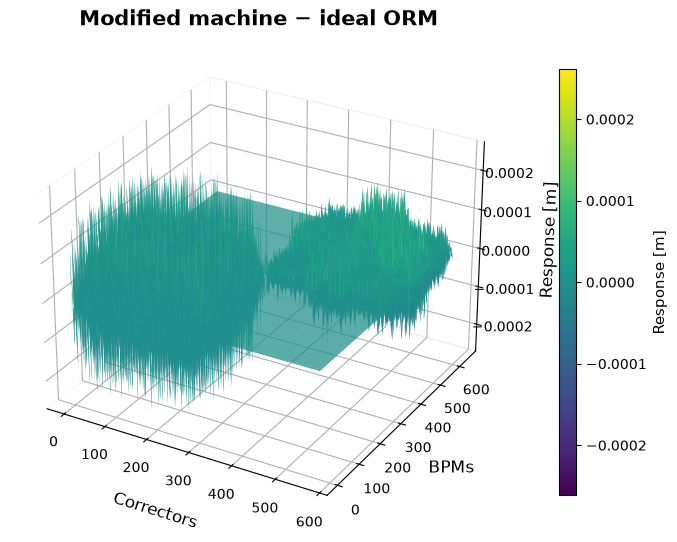

In [9]:
plot_matrices(orm_change, titles=['Modified machine − ideal ORM'], cmap='viridis', plot_type='3d')

## 7. Add reproducible BPM measurement noise

A real ORM contains BPM measurement uncertainty. Here every ORM entry receives independent Gaussian noise with the configured RMS.

In [10]:
noise_rms_m = float(measurement_cfg['bpm_noise_rms_m'])
rng = np.random.default_rng(int(measurement_cfg['random_seed']))
noise = rng.normal(0.0, noise_rms_m, orm_machine.shape)
orm_measured = orm_machine + noise
print(f'Configured noise RMS: {1e6 * noise_rms_m:.6f} µm')
print(f'Generated noise RMS:  {1e6 * np.sqrt(np.mean(noise**2)):.6f} µm')

Configured noise RMS: 0.100000 µm
Generated noise RMS:  0.099844 µm


## 8. Prepare pyLOCO inputs

This example fits only the selected normal-quadrupole strengths. `sigma_w` expresses the same one-sigma BPM uncertainty used to generate the synthetic measurement.

In [11]:
sigma_w = np.full(2 * len(bpm_indices), noise_rms_m)
cm_step = [[kick_rad] * len(corrector_indices)] * 2
fit_cfg = FitInitConfig(fit_list=['quads'], CMstep=cm_step, individuals=True, quads_attr='PolynomB', quads_attr_index=1)
frequency_hz = float(cfg['rf']['frequency_hz'])
rf_step_hz = float(cfg['rf']['step_hz'])
loco_cfg = cfg['loco']
output_dir = config_path.parent / cfg['output']['directory']
temporary_fit_output = TemporaryDirectory(prefix='pyloco_multiple_quads_')
print(f'fit_list = {fit_cfg.fit_list}')
print(f'One-sigma ORM uncertainty = {1e6 * noise_rms_m:.3f} µm')

fit_list = ['quads']
One-sigma ORM uncertainty = 0.100 µm


## 9. Run pyLOCO

pyLOCO changes model parameters until $R_{model}(parameters)\approx R_{measured}$. Its Jacobian describes how each ORM entry responds to a small change of each fitted quadrupole strength.

In [12]:
result = pyloco(
    deepcopy(ideal), algorithm='lm', nIter=int(loco_cfg['nIter']),
    used_bpms_ords=bpm_indices, used_cor_ords=[corrector_indices, corrector_indices],
    quads_ords=quad_indices, skew_ords=np.array([], dtype=int), CAVords=cavity_indices,
    nHBPM=len(bpm_indices), nVBPM=len(bpm_indices),
    nHorCOR=len(corrector_indices), nVerCOR=len(corrector_indices), quads_tilt_ind=quad_indices,
    orm_measured=orm_measured, weights=sigma_w, includeDispersion=False,
    measured_eta_x=np.zeros(len(bpm_indices)), measured_eta_y=np.zeros(len(bpm_indices)),
    CMstep=cm_step, rfStep=rf_step_hz, Frequency=frequency_hz,
    fit_list=['quads'], quad_individuals=True, remove_coupling_=bool(loco_cfg.get('remove_coupling', True)),
    outlier_rejection=False, apply_normalization=bool(loco_cfg.get('apply_normalization', False)),
    normalization_mode=str(loco_cfg.get('normalization_mode', 'component')),
    svd_selection_method=str(loco_cfg['svd_selection_method']), svd_threshold=float(loco_cfg['svd_threshold']),
    cut_=loco_cfg.get('cut'), show_svd_plot=False, nLMIter=int(loco_cfg['nLMIter']),
    Starting_Lambda=float(loco_cfg['Starting_Lambda']), max_lm_lambda=float(loco_cfg['max_lm_lambda']),
    scaled=bool(loco_cfg.get('scaled', True)), plot_fit_parameters=False, auto_correct_delta=True,
    fixedpathlength=False, fixedmomentum=False, fit_cfg=fit_cfg, output_dir=temporary_fit_output.name,
)
_, fit_dict, fitted, fitted_orm, _, chi2_history, _, _ = result
temporary_fit_output.cleanup()


==== Iteration 1/3 – LM ====


[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...


[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_multiple_quads__iec9oth/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 18.8 s
[Jacobian] Saved normal-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_multiple_quads__iec9oth/jacobians/quads/J_quads_iter1_0.0001urad_-3000.0Hz.h5


Initial Chi²: 2.8204e+05


  LM inner 1: chi² 6.6682e+03 (previous 2.8204e+05), λ=0.001


...

[Jacobian] Computing normal-quadrupole Jacobian (iteration 3)...


[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_multiple_quads__iec9oth/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 19.8 s


Initial Chi²: 1.1002e+01


  LM inner 1: chi² 1.2498e+00 (previous 1.1002e+01), λ=0.001


Chi² after correction: 1.2498e+00
LOCO LM completed! :).


## 10. Fit convergence

A decreasing normalized chi-square means that the fitted lattice reproduces the simulated measurement more closely.

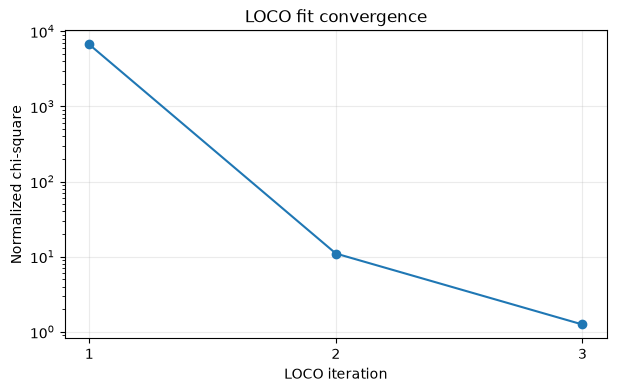

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
iterations = np.arange(1, len(chi2_history) + 1)
ax.semilogy(iterations, chi2_history, 'o-')
ax.set(title='LOCO fit convergence', xlabel='LOCO iteration', ylabel='Normalized chi-square', xticks=iterations)
ax.grid(alpha=0.25)
plt.show()

## 11. Extract the reconstructed error

Both assigned and fitted errors use $\Delta K=K-K_{ideal}$. The correction uses $K_{ideal}-K_{fitted}$ and therefore has the opposite sign.

In [14]:
ideal_k = np.array([ideal[i].PolynomB[1] for i in quad_indices])
fitted_k = np.array([fitted[i].PolynomB[1] for i in quad_indices])
fitted_delta = fitted_k - ideal_k
assigned_delta = np.zeros_like(fitted_delta)
assigned_slots = []
for index, nominal_k, assigned_dk in assigned:
    slot = int(np.flatnonzero(quad_indices == index)[0])
    assigned_slots.append(slot)
    assigned_delta[slot] = assigned_dk
    fitted_dk = fitted_delta[slot]
    print(f'{ideal[index].FamName} [{index}]: assigned={100*assigned_dk/nominal_k:+.6f} %, fitted={100*fitted_dk/nominal_k:+.6f} %, recovery={100*fitted_dk/assigned_dk:.3f} %')
assigned_slots = np.asarray(assigned_slots, dtype=int)

QF4B [42]: assigned=+5.000000 %, fitted=+4.926045 %, recovery=98.521 %
QD3E [1512]: assigned=-3.000000 %, fitted=-2.976115 %, recovery=99.204 %
QD5B [2948]: assigned=+2.000000 %, fitted=+1.986504 %, recovery=99.325 %


## 12. Main result: assigned versus reconstructed error

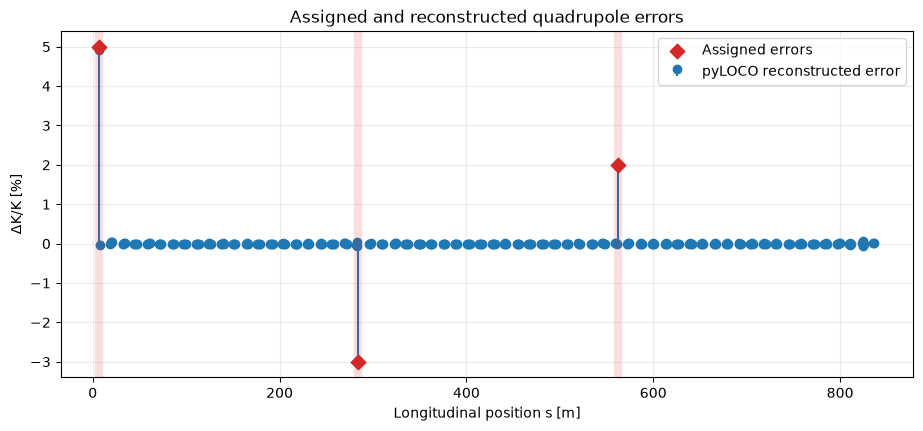

In [15]:
quad_s = at.get_s_pos(ideal, quad_indices)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.stem(quad_s, 100 * fitted_delta / ideal_k, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='pyLOCO reconstructed error')
ax.scatter(quad_s[assigned_slots], 100 * assigned_delta[assigned_slots] / ideal_k[assigned_slots], marker='D', s=55, color='C3', zorder=4, label='Assigned errors')
for slot in assigned_slots: ax.axvline(quad_s[slot], color='C3', alpha=0.15, lw=6)
ax.set(title='Assigned and reconstructed quadrupole errors', xlabel='Longitudinal position s [m]', ylabel='ΔK/K [%]')
ax.grid(alpha=0.25); ax.legend(); plt.show()

## 13. ORM residual before and after LOCO

The initial residual compares the ideal starting model with the measurement. The fitted residual should approach the configured BPM-noise floor.

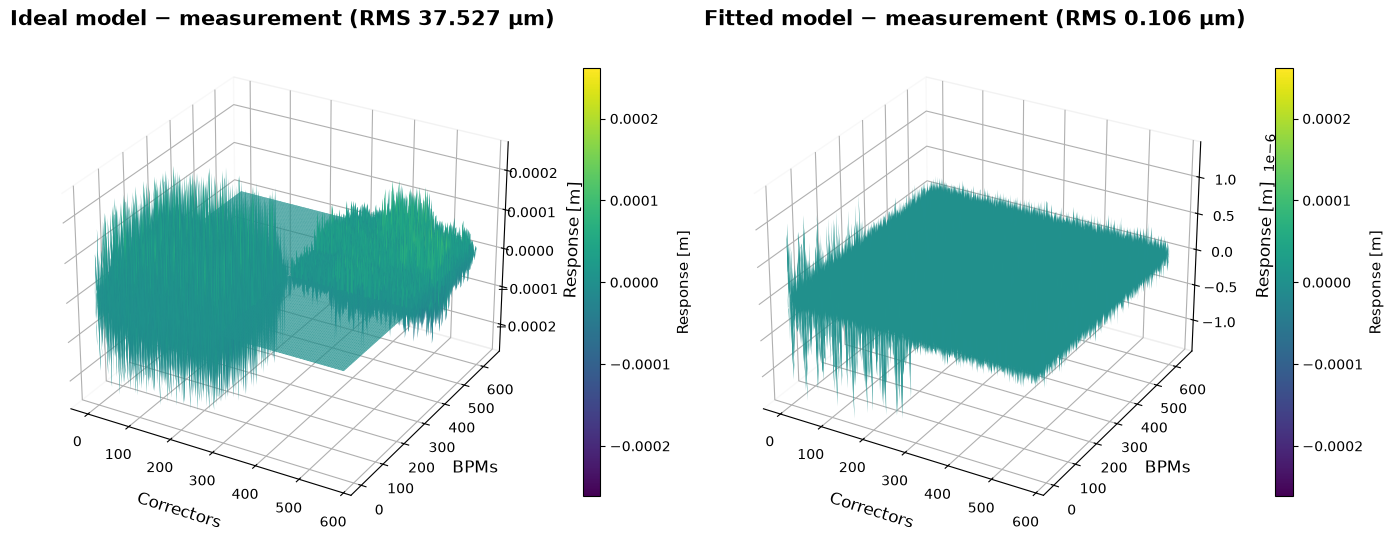

Improvement factor: 354.190x


In [16]:
before = orm_ideal - orm_measured
after = fitted_orm - orm_measured
rms_before = float(np.sqrt(np.mean((orm_ideal - orm_measured)**2)))
rms_after = float(np.sqrt(np.mean((fitted_orm - orm_measured)**2)))
plot_matrices(before, after, titles=[f'Ideal model − measurement (RMS {1e6*rms_before:.3f} µm)', f'Fitted model − measurement (RMS {1e6*rms_after:.3f} µm)'], cmap='viridis', plot_type='3d', same_scale=True)
print(f'Improvement factor: {rms_before / rms_after:.3f}x')

## 14. Apply the correction and validate the optics

The correction is the negative of the reconstructed error. It is applied to the modified machine, whose beta beating should then be much closer to the ideal lattice.

QF4B [42]: correction=-1.185024061e-01, remaining ΔK=+1.779081556e-03 m^-2
QD3E [1512]: correction=-6.860734197e-02, remaining ΔK=+5.506162353e-04 m^-2
QD5B [2948]: correction=+5.503223399e-02, remaining ΔK=-3.738913815e-04 m^-2


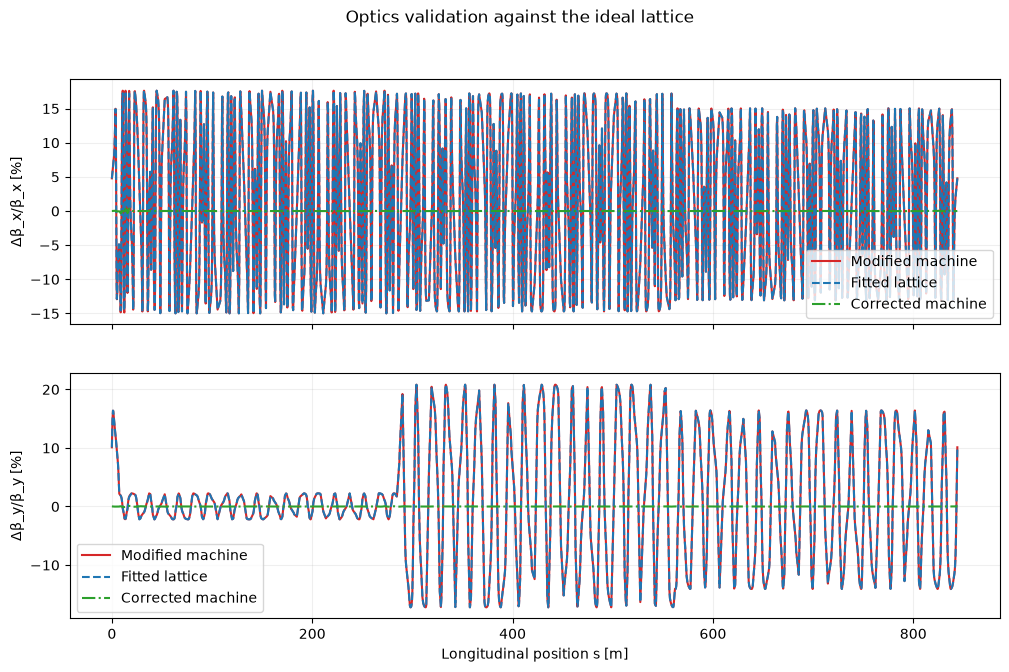

In [17]:
correction_delta = -fitted_delta
corrected_machine = deepcopy(machine)
apply_quadrupole_changes(corrected_machine, quad_indices, correction_delta)
corrected_orm = response_matrix(corrected_machine, config=rm_cfg)
for index, nominal_k, _ in assigned:
    slot = int(np.flatnonzero(quad_indices == index)[0])
    print(f'{ideal[index].FamName} [{index}]: correction={-fitted_delta[slot]:+.9e}, remaining ΔK={corrected_machine[index].K-nominal_k:+.9e} m^-2')
refpts = np.arange(len(ideal) + 1)
s, beta_ideal = optics_beta(ideal, refpts)
_, beta_machine = optics_beta(machine, refpts)
_, beta_fitted = optics_beta(fitted, refpts)
_, beta_corrected = optics_beta(corrected_machine, refpts)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for plane, ax in enumerate(axes):
    ax.plot(s, 100 * (beta_machine[:, plane] - beta_ideal[:, plane]) / beta_ideal[:, plane], label='Modified machine', color='C3')
    ax.plot(s, 100 * (beta_fitted[:, plane] - beta_ideal[:, plane]) / beta_ideal[:, plane], label='Fitted lattice', color='C0', linestyle='--')
    ax.plot(s, 100 * (beta_corrected[:, plane] - beta_ideal[:, plane]) / beta_ideal[:, plane], label='Corrected machine', color='C2', linestyle='-.')
    ax.set_ylabel(f'Δβ_{"xy"[plane]}/β_{"xy"[plane]} [%]'); ax.grid(alpha=0.2); ax.legend()
axes[-1].set_xlabel('Longitudinal position s [m]')
fig.suptitle('Optics validation against the ideal lattice'); plt.show()

## 15. Final numerical summary

In [18]:
print('Multiple-quadrupole reconstruction summary')
print('-------------------------------------------')
print(f'{"Name":<7} {"Index":>6} {"Assigned [%]":>14} {"Fitted [%]":>12} {"Recovery [%]":>14}')
for index, nominal_k, assigned_dk in assigned:
    slot = int(np.flatnonzero(quad_indices == index)[0])
    fitted_dk = fitted_delta[slot]
    print(f'{ideal[index].FamName:<7} {index:6d} {100*assigned_dk/nominal_k:14.6f} {100*fitted_dk/nominal_k:12.6f} {100*fitted_dk/assigned_dk:14.3f}')
print(f'ORM RMS before:            {1e6 * rms_before:.6f} µm')
print(f'ORM RMS after:             {1e6 * rms_after:.6f} µm')
print(f'ORM improvement factor:    {rms_before / rms_after:.3f}x')
print(f'Corrected machine ORM RMS: {1e6 * np.sqrt(np.mean((corrected_orm - orm_ideal)**2)):.6f} µm vs ideal')
print_optics_summary(ideal, [('Modified machine', machine), ('Fitted lattice', fitted), ('Corrected machine', corrected_machine)], orm_ideal, [orm_machine, fitted_orm, corrected_orm])

Multiple-quadrupole reconstruction summary
-------------------------------------------
Name     Index   Assigned [%]   Fitted [%]   Recovery [%]
QF4B        42       5.000000     4.926045         98.521
QD3E      1512      -3.000000    -2.976115         99.204
QD5B      2948       2.000000     1.986504         99.325
ORM RMS before:            37.526761 µm
ORM RMS after:             0.105951 µm
ORM improvement factor:    354.190x
Corrected machine ORM RMS: 0.044959 µm vs ideal



Optics and ORM comparison with the ideal lattice
------------------------------------------------
Lattice                βx RMS [%]   βy RMS [%]   ORM RMS [µm]
Modified machine        10.965927    10.108295      37.526432


Fitted lattice          10.961639    10.108209      37.524909
Corrected machine        0.031598     0.013335       0.044959
